# Lab Assignment 1 — Text-to-Speech Conversion and Performance Analysis

**Course:** Natural Language Processing Lab
**Name:** Jeevant Mudgil  |  **Roll No:** UI23CS30

**Aim:** Write a Python program that accepts text through different input mechanisms,
converts that text into speech, saves a playable audio file, and then studies how the
conversion behaves for different kinds of input text.

**Library used:** `gTTS` (Google Text-to-Speech). It runs on Windows, Linux and macOS,
supports a large number of languages (needed for the language comparison) and produces
an `.mp3` file. It requires an internet connection while converting.

Install the required packages once:

```bash
pip install gTTS matplotlib
```

In [1]:
import os
import time

import matplotlib.pyplot as plt
from gtts import gTTS

INPUT_DIR = "tts_input"      # text files created for the experiments
OUTPUT_DIR = "tts_output"    # generated .mp3 files and saved plots

os.makedirs(INPUT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Input folder :", os.path.abspath(INPUT_DIR))
print("Output folder:", os.path.abspath(OUTPUT_DIR))

Input folder : /home/jeevant/Desktop/NLP_7th/LabAssignment1_TTS/tts_input
Output folder: /home/jeevant/Desktop/NLP_7th/LabAssignment1_TTS/tts_output


In [2]:
def count_paragraphs(text):
    """A paragraph is a non-empty block of text separated from the next by a blank line."""
    blocks = text.strip().split("\n\n")
    return len([block for block in blocks if block.strip()])


def convert_to_speech(text, audio_name, lang="en"):
    """Convert `text` into speech, save the mp3 in OUTPUT_DIR and return (path, stats)."""
    audio_path = os.path.join(OUTPUT_DIR, audio_name)

    start = time.perf_counter()
    gTTS(text=text, lang=lang).save(audio_path)
    conversion_time = time.perf_counter() - start

    stats = {
        "words": len(text.split()),
        "conversion_time": conversion_time,
        "audio_name": audio_name,
        "audio_size": os.path.getsize(audio_path),
    }
    return audio_path, stats


def print_stats(stats, input_desc):
    print("Input                :", input_desc)
    print("Number of words      :", stats["words"])
    print("Conversion time      :", round(stats["conversion_time"], 4), "seconds")
    print("Output audio filename:", stats["audio_name"])
    print("Output audio file size:", stats["audio_size"], "bytes")

## 1. Input Modes

The program has to accept text in three different ways. Each mode is implemented below
as a separate step.

### 1.1 Static Text Input

In [3]:
static_text = (
    "Text to speech conversion reads written text and produces spoken audio. "
    "It is used in screen readers, voice assistants and language learning tools."
)

static_audio, static_stats = convert_to_speech(static_text, "static_output.mp3")

print_stats(static_stats, static_text)

Input                : Text to speech conversion reads written text and produces spoken audio. It is used in screen readers, voice assistants and language learning tools.
Number of words      : 23
Conversion time      : 1.71 seconds
Output audio filename: static_output.mp3
Output audio file size: 88128 bytes


### 1.2 Dynamic / User Input

The text is taken from the user at run time using `input()`.

In [4]:
try:
    user_text = input("Enter the text to convert into speech: ").strip()
except (EOFError, NotImplementedError):
    # Raised when the notebook is executed without a keyboard, for example when all
    # the cells are run as a batch job. A sample sentence is used in that case.
    user_text = "Interactive input was not available, so this sample sentence is used."
    print("No interactive input available, using:", user_text)

if not user_text:
    user_text = "No text was entered, so this default sentence is read aloud."

dynamic_audio, dynamic_stats = convert_to_speech(user_text, "dynamic_output.mp3")

print_stats(dynamic_stats, user_text)

Input                : Hi, I am here to help you
Number of words      : 7
Conversion time      : 0.3626 seconds
Output audio filename: dynamic_output.mp3
Output audio file size: 21312 bytes


### 1.3 Text File Input

A text file is created (if it is not present already), read completely and converted.
For this mode the assignment also asks for the input file size and the number of
paragraphs.

In [5]:
sample_file = os.path.join(INPUT_DIR, "sample_text.txt")

if not os.path.exists(sample_file):
    with open(sample_file, "w", encoding="utf-8") as f:
        f.write(
            "Speech synthesis converts written text into spoken audio.\n\n"
            "A text to speech system first analyses the sentence structure, then it "
            "predicts the pronunciation of every word, and finally it generates the "
            "audio waveform.\n\n"
            "The quality of the generated speech depends on the voice model, the "
            "language, and the punctuation present in the text."
        )

with open(sample_file, "r", encoding="utf-8") as f:
    file_text = f.read()

file_audio, file_stats = convert_to_speech(file_text, "file_output.mp3")

print("Input file size      :", os.path.getsize(sample_file), "bytes")
print("Number of words      :", file_stats["words"])
print("Number of paragraphs :", count_paragraphs(file_text))
print("Conversion time      :", round(file_stats["conversion_time"], 4), "seconds")
print("Output audio filename:", file_stats["audio_name"])
print("Output audio file size:", file_stats["audio_size"], "bytes")

Input file size      : 336 bytes
Number of words      : 53
Number of paragraphs : 3
Conversion time      : 4.4038 seconds
Output audio filename: file_output.mp3
Output audio file size: 198528 bytes


In [6]:
from IPython.display import Audio, display

display(Audio(file_audio))

## 2. Performance Analysis

All the experiments below use the **text-file input mode**. Conversion time is measured
with `time.perf_counter()` around the `gTTS` call, so it covers the full round trip of
sending the text and receiving the audio. Since `gTTS` works over the network, the actual
values depend on the internet speed of the machine and may differ slightly between runs.

### Dataset preparation

Two small helpers are used to build the test files:
`build_text()` produces a text of an exact number of words, and `build_paragraphs()`
breaks the same number of words into a given number of paragraphs.

In [7]:
SENTENCES = [
    "Natural language processing helps computers understand human language.",
    "A corpus is a large collection of text used for linguistic research.",
    "Speech synthesis converts written words into spoken audio.",
    "Machine learning models learn patterns from large amounts of data.",
    "Grammar and vocabulary together decide the meaning of a sentence.",
    "Text analytics is used in search engines and recommendation systems.",
    "Automatic translation allows people to read text written in other languages.",
    "Punctuation gives the reader information about pauses and sentence boundaries.",
    "Voice assistants answer questions using speech recognition and synthesis.",
    "Language models are trained on books, articles and web pages.",
]


def build_text(word_count):
    """Build a text of exactly `word_count` words by repeating the sentence pool."""
    words = []
    index = 0
    while len(words) < word_count:
        words.extend(SENTENCES[index % len(SENTENCES)].split())
        index += 1
    return " ".join(words[:word_count])


def build_paragraphs(total_words, paragraph_count):
    """Split `total_words` words into `paragraph_count` roughly equal paragraphs."""
    words = build_text(total_words).split()
    per_paragraph = total_words // paragraph_count

    paragraphs = []
    for i in range(paragraph_count):
        start = i * per_paragraph
        end = total_words if i == paragraph_count - 1 else start + per_paragraph
        paragraphs.append(" ".join(words[start:end]))

    return "\n\n".join(paragraphs)

### 2.1 Effect of Number of Words

Three files of approximately 500, 1000 and 2000 words are created and converted.

In [8]:
word_targets = [500, 1000, 2000]
word_results = []

for target in word_targets:
    text = build_text(target)
    text_file = os.path.join(INPUT_DIR, f"words_{target}.txt")
    with open(text_file, "w", encoding="utf-8") as f:
        f.write(text)

    print(f"Converting words_{target}.txt ({len(text.split())} words) ...")
    _, stats = convert_to_speech(text, f"words_{target}.mp3")
    word_results.append((target, stats["conversion_time"], stats["audio_size"] / 1024))

print()
print(f"{'Words':>6} | {'Conversion time (s)':>19} | {'Audio size (KB)':>15}")
print("-" * 48)
for words, conv_time, size_kb in word_results:
    print(f"{words:>6} | {conv_time:>19.4f} | {size_kb:>15.2f}")

Converting words_500.txt (500 words) ...
Converting words_1000.txt (1000 words) ...
Converting words_2000.txt (2000 words) ...

 Words | Conversion time (s) | Audio size (KB)
------------------------------------------------
   500 |             42.0541 |         2005.50
  1000 |             45.3609 |         3993.94
  2000 |             94.7155 |         7981.31


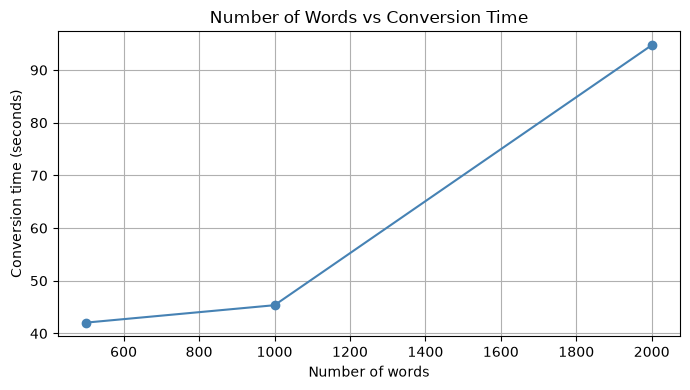

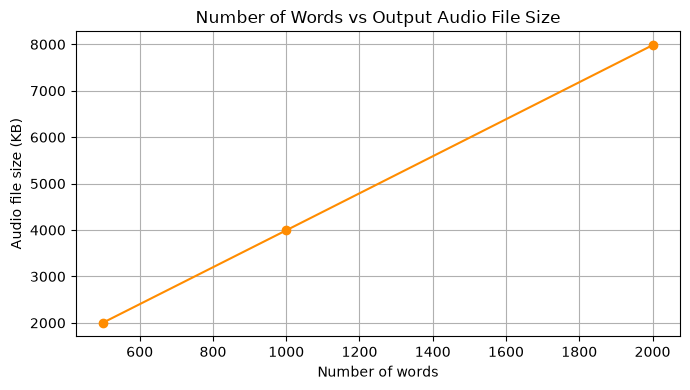

In [9]:
words = [row[0] for row in word_results]
times = [row[1] for row in word_results]
sizes = [row[2] for row in word_results]

plt.figure(figsize=(7, 4))
plt.plot(words, times, marker="o", color="steelblue")
plt.title("Number of Words vs Conversion Time")
plt.xlabel("Number of words")
plt.ylabel("Conversion time (seconds)")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "words_vs_time.png"), dpi=150)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(words, sizes, marker="o", color="darkorange")
plt.title("Number of Words vs Output Audio File Size")
plt.xlabel("Number of words")
plt.ylabel("Audio file size (KB)")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "words_vs_size.png"), dpi=150)
plt.show()

### 2.2 Effect of Number of Paragraphs

The total number of words is kept constant at 1000, and only the way the text is broken
into paragraphs is changed (5, 10 and 20 paragraphs).

In [10]:
TOTAL_WORDS = 1000
paragraph_targets = [5, 10, 20]
paragraph_results = []

for count in paragraph_targets:
    text = build_paragraphs(TOTAL_WORDS, count)
    text_file = os.path.join(INPUT_DIR, f"paragraphs_{count}.txt")
    with open(text_file, "w", encoding="utf-8") as f:
        f.write(text)

    print(f"paragraphs_{count}.txt -> {len(text.split())} words, "
          f"{count_paragraphs(text)} paragraphs")

    _, stats = convert_to_speech(text, f"paragraphs_{count}.mp3")
    paragraph_results.append((count, stats["conversion_time"]))

print()
for count, conv_time in paragraph_results:
    print(f"{count:>2} paragraphs -> {conv_time:.4f} seconds")

paragraphs_5.txt -> 1000 words, 5 paragraphs
paragraphs_10.txt -> 1000 words, 10 paragraphs
paragraphs_20.txt -> 1000 words, 20 paragraphs

 5 paragraphs -> 48.0174 seconds
10 paragraphs -> 53.2779 seconds
20 paragraphs -> 58.0188 seconds


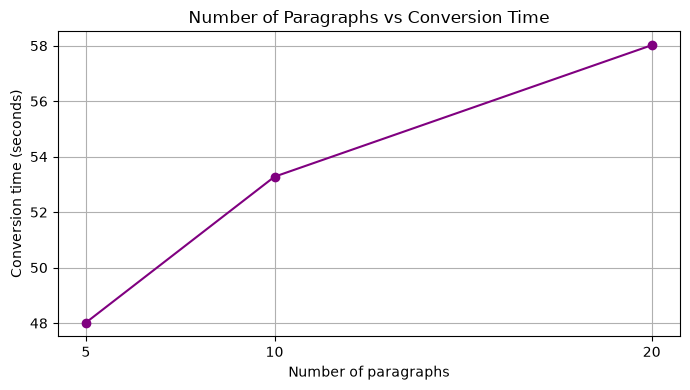

In [11]:
plt.figure(figsize=(7, 4))
plt.plot(
    [row[0] for row in paragraph_results],
    [row[1] for row in paragraph_results],
    marker="o",
    color="purple",
)
plt.title("Number of Paragraphs vs Conversion Time")
plt.xlabel("Number of paragraphs")
plt.ylabel("Conversion time (seconds)")
plt.xticks(paragraph_targets)
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "paragraphs_vs_time.png"), dpi=150)
plt.show()

### 2.3 Effect of Special Characters

Four texts of comparable length are created:

| File | Content |
|------|---------|
| A | Normal text, no special characters |
| B | Same words with punctuation (`, ; : !`) |
| C | Same words, but one word in every six replaced by `@#$%&` |
| D | Mixed — `$100%` style tokens together with `;` and `?` |

Texts B, C and D keep the token count of text A so that the comparison is fair.

In [12]:
base_words = build_text(60).split()

text_a = " ".join(base_words)

text_b = ", ".join(" ".join(base_words[i:i + 6]) for i in range(0, len(base_words), 6)) + "!"

symbol_words = list(base_words)
for i in range(4, len(symbol_words), 6):
    symbol_words[i] = "@#$%&"
text_c = " ".join(symbol_words)

mixed_words = list(base_words)
for i in range(4, len(mixed_words), 6):
    mixed_words[i] = "$100%"
text_d = "; ".join(" ".join(mixed_words[i:i + 6]) for i in range(0, len(mixed_words), 6)) + "?"

special_texts = {
    "A - Normal": text_a,
    "B - Punctuation": text_b,
    "C - Symbols": text_c,
    "D - Mixed": text_d,
}

for label, text in special_texts.items():
    print(f"{label:<16} tokens = {len(text.split())}")

A - Normal       tokens = 60
B - Punctuation  tokens = 60
C - Symbols      tokens = 60
D - Mixed        tokens = 60


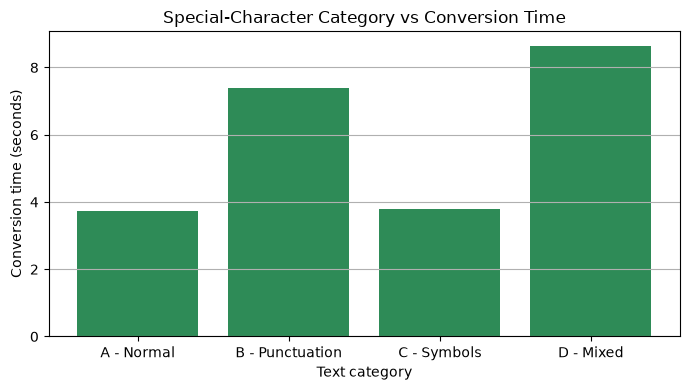


A - Normal       -> 3.7252 seconds
B - Punctuation  -> 7.3891 seconds
C - Symbols      -> 3.7834 seconds
D - Mixed        -> 8.6431 seconds


In [13]:
special_results = []

for label, text in special_texts.items():
    text_file = os.path.join(INPUT_DIR, f"special_{label[0]}.txt")
    with open(text_file, "w", encoding="utf-8") as f:
        f.write(text)

    _, stats = convert_to_speech(text, f"special_{label[0]}.mp3")
    special_results.append((label, stats["conversion_time"]))

plt.figure(figsize=(7, 4))
plt.bar(
    [row[0] for row in special_results],
    [row[1] for row in special_results],
    color="seagreen",
)
plt.title("Special-Character Category vs Conversion Time")
plt.xlabel("Text category")
plt.ylabel("Conversion time (seconds)")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "special_chars_vs_time.png"), dpi=150)
plt.show()

print()
for label, conv_time in special_results:
    print(f"{label:<16} -> {conv_time:.4f} seconds")

**Observation about special characters**

What the speech engine does with the characters, and what happens to the conversion time,
are two separate questions.

- **Text A (normal)** is read as a plain sentence.
- **Text B (punctuation)** contains exactly the same 60 words as A, so the spoken content is
  the same. The commas and the final `!` are not read as words; they only add short pauses
  and change the intonation. Punctuation is therefore *interpreted*.
- **Text C (symbols)** replaces one word in every six with `@#$%&`. These symbols are not
  pronounced as words — the speech engine drops them — so part of the sentence is missing
  from the audio. Standalone symbols are therefore *ignored*.
- **Text D (mixed)** combines both cases. Symbols attached to digits are *interpreted* rather
  than ignored: `$100%` is spoken as "one hundred percent", while the semicolons behave like
  commas.

The times printed above show the two punctuation-heavy texts (B and D) taking longer than A
and C, which is consistent with punctuation adding pauses. The gap is also of the same order
as the run-to-run variation described in section 2.2, though, so the timings should be read
as an indication and not as a fixed property of each category.

### 2.4 Repeated vs Different Text

File A contains the same sentence repeated, so its vocabulary is very small. File B has
the same number of words but uses varied vocabulary.

In [14]:
repeated_text = "Natural language processing helps computers understand human language. " * 12
varied_text = build_text(len(repeated_text.split()))

with open(os.path.join(INPUT_DIR, "repeated.txt"), "w", encoding="utf-8") as f:
    f.write(repeated_text)
with open(os.path.join(INPUT_DIR, "varied.txt"), "w", encoding="utf-8") as f:
    f.write(varied_text)

repeat_results = []
for label, text, audio_name in [
    ("Repeated (File A)", repeated_text, "repeated.mp3"),
    ("Varied (File B)", varied_text, "varied.mp3"),
]:
    print(f"{label}: {len(text.split())} words, "
          f"{len(set(text.lower().split()))} unique words")
    _, stats = convert_to_speech(text, audio_name)
    repeat_results.append((label, stats["conversion_time"]))

Repeated (File A): 96 words, 8 unique words
Varied (File B): 96 words, 77 unique words


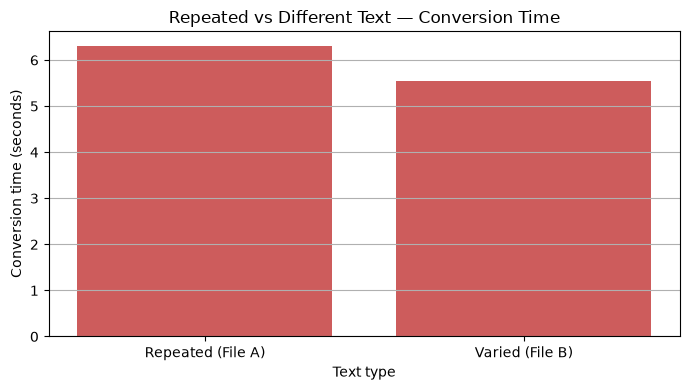


Repeated (File A)  -> 6.3070 seconds
Varied (File B)    -> 5.5483 seconds


In [15]:
plt.figure(figsize=(7, 4))
plt.bar(
    [row[0] for row in repeat_results],
    [row[1] for row in repeat_results],
    color="indianred",
)
plt.title("Repeated vs Different Text — Conversion Time")
plt.xlabel("Text type")
plt.ylabel("Conversion time (seconds)")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "repeated_vs_different_time.png"), dpi=150)
plt.show()

print()
for label, conv_time in repeat_results:
    print(f"{label:<18} -> {conv_time:.4f} seconds")

### 2.5 Language Comparison

The same idea is converted into four languages that `gTTS` supports.

In [16]:
language_texts = {
    "English": ("Artificial intelligence is changing the way computers understand language.", "en"),
    "Hindi": ("कृत्रिम बुद्धिमत्ता वह तरीका बदल रही है जिससे कंप्यूटर भाषा समझते हैं।", "hi"),
    "Spanish": ("La inteligencia artificial está cambiando la forma en que las computadoras entienden el lenguaje.", "es"),
    "French": ("L'intelligence artificielle change la façon dont les ordinateurs comprennent le langage.", "fr"),
}

language_results = []

for language, (text, code) in language_texts.items():
    print(f"{language} ({code}): {len(text.split())} words")
    _, stats = convert_to_speech(text, f"language_{code}.mp3", lang=code)
    language_results.append((language, stats["conversion_time"]))

English (en): 9 words
Hindi (hi): 12 words
Spanish (es): 14 words
French (fr): 11 words


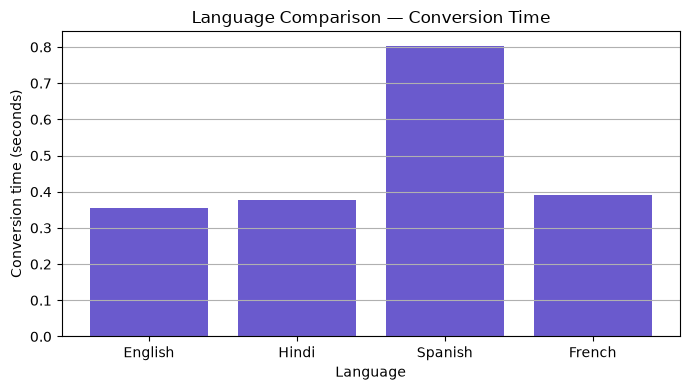


English    -> 0.3545 seconds
Hindi      -> 0.3765 seconds
Spanish    -> 0.8032 seconds
French     -> 0.3906 seconds


In [17]:
plt.figure(figsize=(7, 4))
plt.bar(
    [row[0] for row in language_results],
    [row[1] for row in language_results],
    color="slateblue",
)
plt.title("Language Comparison — Conversion Time")
plt.xlabel("Language")
plt.ylabel("Conversion time (seconds)")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "language_comparison_time.png"), dpi=150)
plt.show()

print()
for language, conv_time in language_results:
    print(f"{language:<10} -> {conv_time:.4f} seconds")

## 3. Result Summary

All the plots required by the assignment are saved inside the output folder so they can
be used directly in the lab report.

In [18]:
print("Files generated in", os.path.abspath(OUTPUT_DIR), ":\n")

for name in sorted(os.listdir(OUTPUT_DIR)):
    size_kb = os.path.getsize(os.path.join(OUTPUT_DIR, name)) / 1024
    print(f"  {name:<36} {size_kb:>8.2f} KB")

Files generated in /home/jeevant/Desktop/NLP_7th/LabAssignment1_TTS/tts_output :

  dynamic_output.mp3                      20.81 KB
  file_output.mp3                        193.88 KB
  language_comparison_time.png            31.50 KB
  language_en.mp3                         41.44 KB
  language_es.mp3                         57.00 KB
  language_fr.mp3                         42.75 KB
  language_hi.mp3                         51.00 KB
  paragraphs_10.mp3                     4016.44 KB
  paragraphs_20.mp3                     4039.12 KB
  paragraphs_5.mp3                      4001.06 KB
  paragraphs_vs_time.png                  42.22 KB
  repeated.mp3                           486.94 KB
  repeated_vs_different_time.png          30.77 KB
  special_A.mp3                          238.31 KB
  special_B.mp3                          269.25 KB
  special_C.mp3                          336.00 KB
  special_D.mp3                          367.69 KB
  special_chars_vs_time.png               32.04 KB


## 4. Conclusion

- A single reusable function (`convert_to_speech`) handles all three input modes — static
  text, user input and text file input — and returns all the statistics the assignment asks
  for.
- **Number of words:** this is the clearest result of the experiment. Conversion time and
  audio file size both grow steadily as the text gets longer, because more text has to be
  sent and more audio has to be generated. The table above shows roughly proportional growth
  from 500 to 2000 words.
- **Number of paragraphs:** the word count is held at 1000 in all three runs, so the amount
  of text sent is identical and the paragraph breaks are the only thing that changes. The
  times printed above do differ from each other, but those three runs happen several minutes
  apart, so the difference reflects the network and server load at that moment rather than
  the paragraph structure. A single run is not enough to claim a trend here; the experiment
  would have to be repeated several times to say anything reliable about paragraphs.
- **Special characters:** punctuation is interpreted (it adds pauses and changes intonation),
  standalone symbols such as `@ # $ % &` are ignored, and symbols attached to digits
  (`$100%`) are interpreted and spoken as a quantity.
- **Repeated vs different text:** both files have the same number of words and their times
  above are close to each other. One file has a tiny vocabulary and the other a large one,
  yet the work done is the same — the time depends on how much text is sent, not on how many
  distinct words it contains.
- **Languages:** all four languages are converted successfully and their times are all of the
  same order of magnitude (well under a second in this run). The four sentences do not have
  exactly the same word count, so the small differences cannot be attributed to the language
  itself.

The one thing all five experiments have in common is that `gTTS` performs the conversion on a
remote server. The conversion time therefore measures the network round trip as much as the
synthesis work, and the values should be read as approximate measurements rather than as
fixed properties of the library.